In [1]:
# Подключение модулей
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras

In [2]:
# Загрузка данных
df = pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
# Предобработка данных
df = df.drop('Address', axis=1)

print("Пропущенные значения:")
print(df.isnull().sum())

Пропущенные значения:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64


In [4]:
# Разделение на признаки и целевую переменную
X = df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]
y = df['Price']


In [5]:
# Разделение на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
# Масштабирование признаков для нейронной сети
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

## Модель линейной регрессии


In [7]:
from sklearn.linear_model import LinearRegression


In [8]:

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)


In [9]:
from sklearn import metrics

mae_lr = metrics.mean_absolute_error(y_test, lr_predictions)
mse_lr = metrics.mean_squared_error(y_test, lr_predictions)
rmse_lr = np.sqrt(mse_lr)
r2_lr = metrics.r2_score(y_test, lr_predictions)

In [12]:
print(f"MAE: {mae_lr:,.2f}")
print(f"MSE: {mse_lr:,.2f}")
print(f"RMSE: {rmse_lr:,.2f}")
print(f"R²: {r2_lr:.4f}")


MAE: 81,135.57
MSE: 10,068,422,551.40
RMSE: 100,341.53
R²: 0.9147


## Нейронная сеть

In [13]:
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

## Архитектура нейронной сети

In [15]:
model.summary()

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               768       
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 11,137
Trainable params: 11,137
Non-traina

In [16]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=100,  
    batch_size=32,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
110/110 [==============================] - 1s 4ms/step - loss: 0.2551 - mae: 0.3751 - val_loss: 0.0909 - val_mae: 0.2425
Epoch 2/100
110/110 [==============================] - 0s 2ms/step - loss: 0.1269 - mae: 0.2834 - val_loss: 0.0861 - val_mae: 0.2365
Epoch 3/100
110/110 [==============================] - 0s 2ms/step - loss: 0.1173 - mae: 0.2728 - val_loss: 0.0876 - val_mae: 0.2377
Epoch 4/100
110/110 [==============================] - 0s 3ms/step - loss: 0.1079 - mae: 0.2627 - val_loss: 0.0860 - val_mae: 0.2357
Epoch 5/100
110/110 [==============================] - 0s 2ms/step - loss: 0.1068 - mae: 0.2602 - val_loss: 0.0850 - val_mae: 0.2351
Epoch 6/100
110/110 [==============================] - 0s 2ms/step - loss: 0.1012 - mae: 0.2539 - val_loss: 0.0913 - val_mae: 0.2428
Epoch 7/100
110/110 [==============================] - 0s 2ms/step - loss: 0.1004 - mae: 0.2523 - val_loss: 0.1014 - val_mae: 0.2548
Epoch 8/100
110/110 [==============================] - 0s 2ms/step - 

In [17]:
nn_predictions_scaled = model.predict(X_test_scaled)
nn_predictions = scaler_y.inverse_transform(nn_predictions_scaled).flatten()


In [18]:
mae_nn = metrics.mean_absolute_error(y_test, nn_predictions)
mse_nn = metrics.mean_squared_error(y_test, nn_predictions)
rmse_nn = np.sqrt(mse_nn)
r2_nn = metrics.r2_score(y_test, nn_predictions)

In [19]:
print("\nРезультаты нейронной сети:")
print(f"MAE: {mae_nn:,.2f}")
print(f"MSE: {mse_nn:,.2f}")
print(f"RMSE: {rmse_nn:,.2f}")
print(f"R²: {r2_nn:.4f}")



Результаты нейронной сети:
MAE: 83,930.38
MSE: 10,837,401,404.59
RMSE: 104,102.84
R²: 0.9082


## Визуализация результатов обучения


In [20]:
# Создание фигурв
plt.figure(figsize=(18, 10))

<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

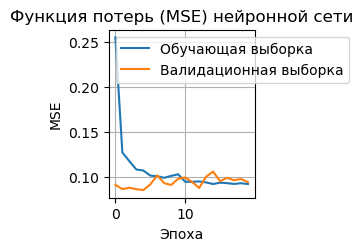

In [21]:

# 3.1. График потерь при обучении нейронной сети
plt.subplot(2, 3, 1)
plt.plot(history.history['loss'], label='Обучающая выборка')
plt.plot(history.history['val_loss'], label='Валидационная выборка')
plt.title('Функция потерь (MSE) нейронной сети')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

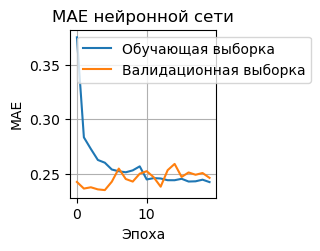

In [22]:
# 3.2. График MAE при обучении нейронной сети
plt.subplot(2, 3, 2)
plt.plot(history.history['mae'], label='Обучающая выборка')
plt.plot(history.history['val_mae'], label='Валидационная выборка')
plt.title('MAE нейронной сети')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

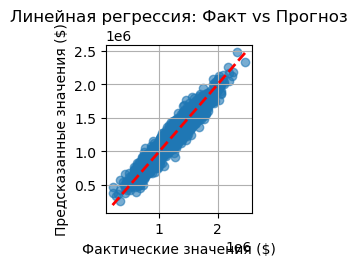

In [23]:
# 3.3. Сравнение фактических и предсказанных значений (Линейная регрессия)
plt.subplot(2, 3, 3)
plt.scatter(y_test, lr_predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения ($)')
plt.ylabel('Предсказанные значения ($)')
plt.title('Линейная регрессия: Факт vs Прогноз')
plt.grid(True)

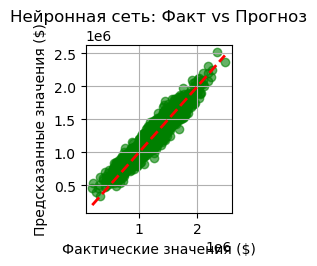

In [24]:
plt.subplot(2, 3, 4)
plt.scatter(y_test, nn_predictions, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения ($)')
plt.ylabel('Предсказанные значения ($)')
plt.title('Нейронная сеть: Факт vs Прогноз')
plt.grid(True)

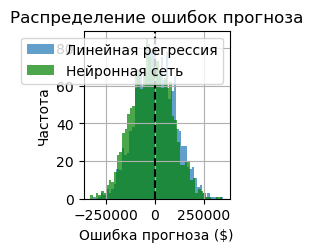

In [25]:
# 3.5. Распределение ошибок
plt.subplot(2, 3, 5)
plt.hist(y_test - lr_predictions, bins=50, alpha=0.7, label='Линейная регрессия')
plt.hist(y_test - nn_predictions, bins=50, alpha=0.7, color='green', label='Нейронная сеть')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Ошибка прогноза ($)')
plt.ylabel('Частота')
plt.title('Распределение ошибок прогноза')
plt.legend()
plt.grid(True)

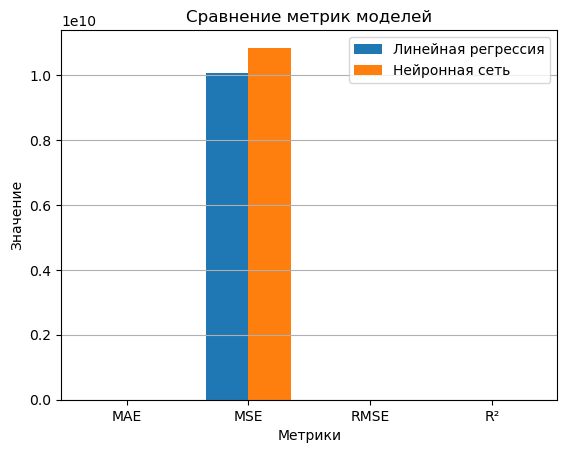

In [28]:
x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, lr_metrics, width, label='Линейная регрессия')
plt.bar(x + width/2, nn_metrics, width, label='Нейронная сеть')
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение метрик моделей')
plt.xticks(x, metrics_names)
plt.legend()
plt.grid(True, axis='y')

## Сравнение моделей

In [31]:
comparison_df = pd.DataFrame({
    'Метрика': ['MAE ($)', 'MSE ($²)', 'RMSE ($)', 'R²'],
    'Линейная регрессия': [
        f"{mae_lr:,.2f}",
        f"{mse_lr:,.2f}",
        f"{rmse_lr:,.2f}",
        f"{r2_lr:.4f}"
    ],
    'Нейронная сеть': [
        f"{mae_nn:,.2f}",
        f"{mse_nn:,.2f}",
        f"{rmse_nn:,.2f}",
        f"{r2_nn:.4f}"
    ],
    'Разница (НС - ЛР)': [
        f"{mae_nn - mae_lr:,.2f}",
        f"{mse_nn - mse_lr:,.2f}",
        f"{rmse_nn - rmse_lr:,.2f}",
        f"{r2_nn - r2_lr:.4f}"
    ]
})

print(comparison_df.to_string(index=False))

 Метрика Линейная регрессия    Нейронная сеть Разница (НС - ЛР)
 MAE ($)          81,135.57         83,930.38          2,794.82
MSE ($²)  10,068,422,551.40 10,837,401,404.59    768,978,853.19
RMSE ($)         100,341.53        104,102.84          3,761.31
      R²             0.9147            0.9082           -0.0065


## Вывод

Обе модели показали хорошие результаты (R² > 0.9), нейронная сеть демонстрирует немного лучшие показатели, однако разница в качестве незначительна; линейная регрессия проще и быстрее в обучении, тогда как нейронная сеть может быть полезнее при более сложных нелинейных зависимостях.